In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('GAMBAR_NAMA.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

### Deteksi Warna Citra

In [3]:
hapus_biru  = img_rgb.copy()
hapus_merah = img_rgb.copy()
hapus_hijau = img_rgb.copy()

In [4]:
# Biru
mask_biru_rgb = (img_rgb[:,:,2] > 100) & (img_rgb[:,:,2] > img_rgb[:,:,0]) & (img_rgb[:,:,2] > img_rgb[:,:,1])
hapus_biru[mask_biru_rgb] = [255,255,255]

# Merah
mask_merah_rgb = (img_rgb[:,:,0] > 100) & (img_rgb[:,:,0] > img_rgb[:,:,1]) & (img_rgb[:,:,0] > img_rgb[:,:,2])
hapus_merah[mask_merah_rgb] = [255,255,255]

# Hijau
mask_hijau_rgb = (img_rgb[:,:,1] > 100) & (img_rgb[:,:,1] > img_rgb[:,:,0]) & (img_rgb[:,:,1] > img_rgb[:,:,2])
hapus_hijau[mask_hijau_rgb] = [255,255,255]

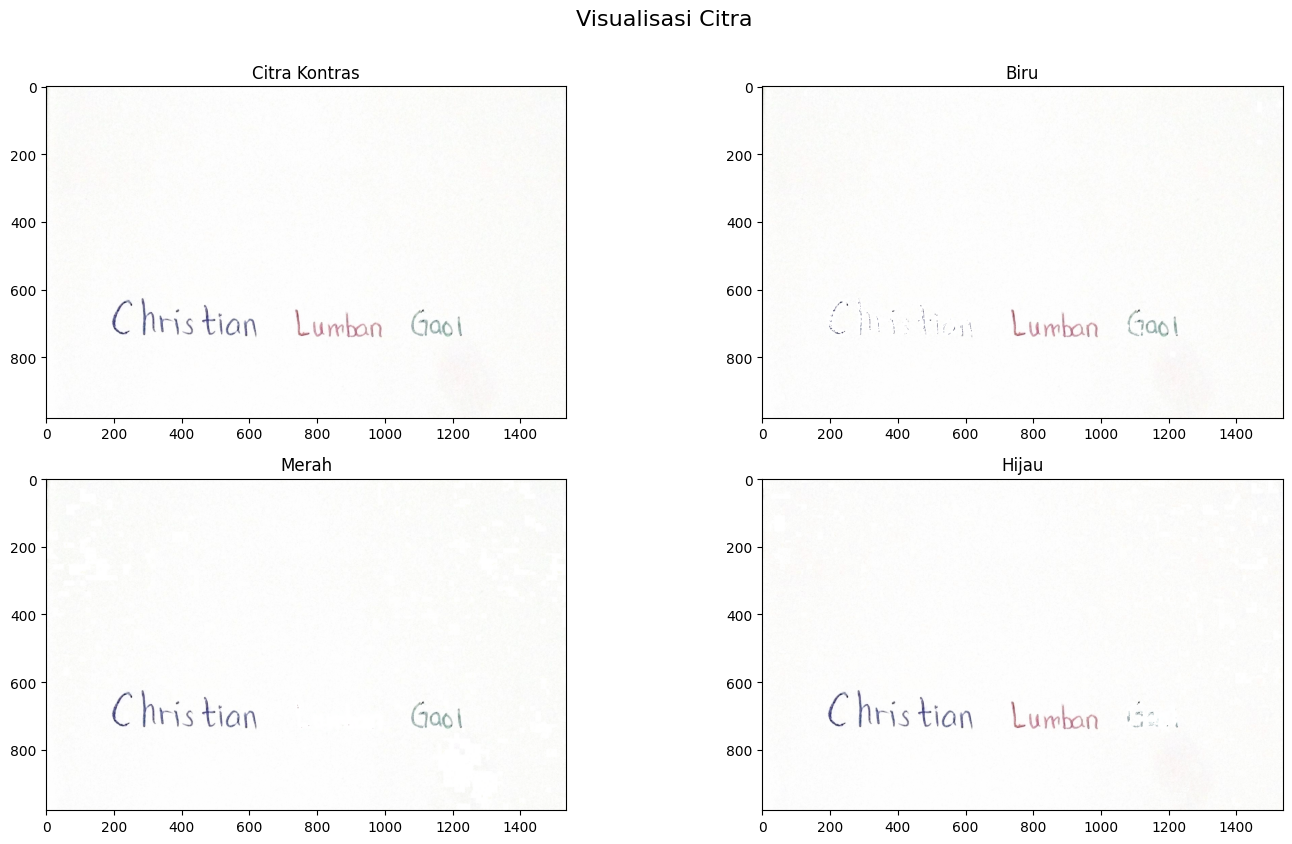

In [5]:
plt.figure(figsize=(15,8))
plt.subplot(2,2,1); plt.imshow(img_rgb); plt.title("Citra Kontras"); plt.axis('on')
plt.subplot(2,2,2); plt.imshow(hapus_biru); plt.title("Biru"); plt.axis('on')
plt.subplot(2,2,3); plt.imshow(hapus_merah); plt.title("Merah"); plt.axis('on')
plt.subplot(2,2,4); plt.imshow(hapus_hijau); plt.title("Hijau"); plt.axis('on')
plt.tight_layout(); plt.suptitle("Visualisasi Citra", fontsize=16, y=1.05); plt.show()

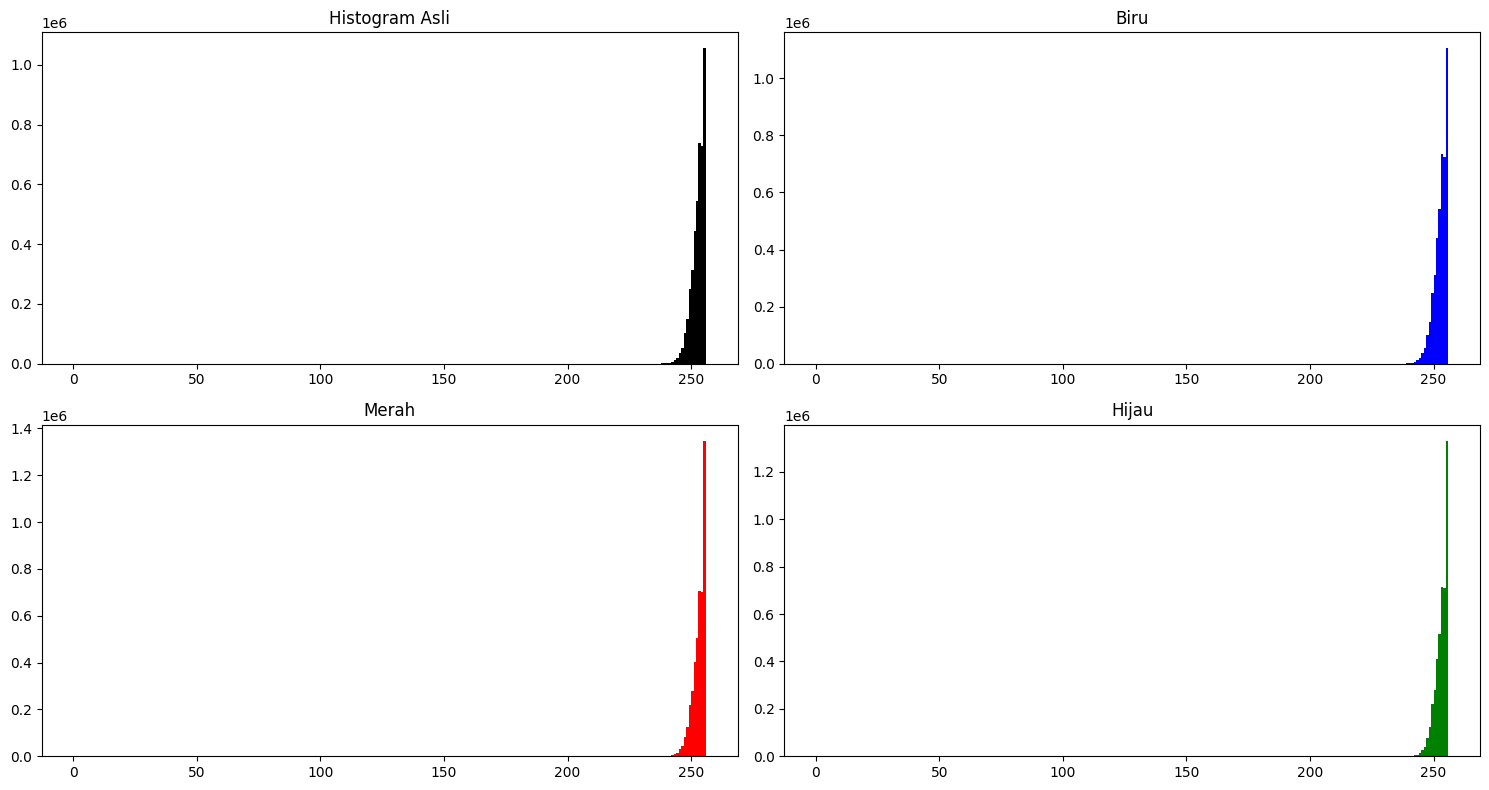

In [6]:
plt.figure(figsize=(15,8))
plt.subplot(2,2,1); plt.hist(img_rgb.ravel(), 256, range=[0,256], color='black'); plt.title("Histogram Asli")
plt.subplot(2,2,2); plt.hist(hapus_biru.ravel(), 256, range=[0,256], color='blue'); plt.title("Biru")
plt.subplot(2,2,3); plt.hist(hapus_merah.ravel(), 256, range=[0,256], color='red'); plt.title("Merah")
plt.subplot(2,2,4); plt.hist(hapus_hijau.ravel(), 256, range=[0,256], color='green'); plt.title("Hijau")
plt.tight_layout(); plt.show()

### Nilai Ambang Batas Citra

In [7]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [8]:
lower_blue = np.array([100, 50, 50]); upper_blue = np.array([130, 255, 255])
lower_red1 = np.array([0, 70, 50]); upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50]); upper_red2 = np.array([180, 255, 255])
lower_green = np.array([35, 40, 40]); upper_green = np.array([90, 255, 255])

m_blue = cv2.inRange(hsv, lower_blue, upper_blue)
m_red  = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1), cv2.inRange(hsv, lower_red2, upper_red2))
m_green = cv2.inRange(hsv, lower_green, upper_green)

none_img = np.zeros_like(m_blue)
only_blue = m_blue
red_blue = cv2.bitwise_or(m_red, m_blue)
red_green_blue = cv2.bitwise_or(red_blue, m_green)

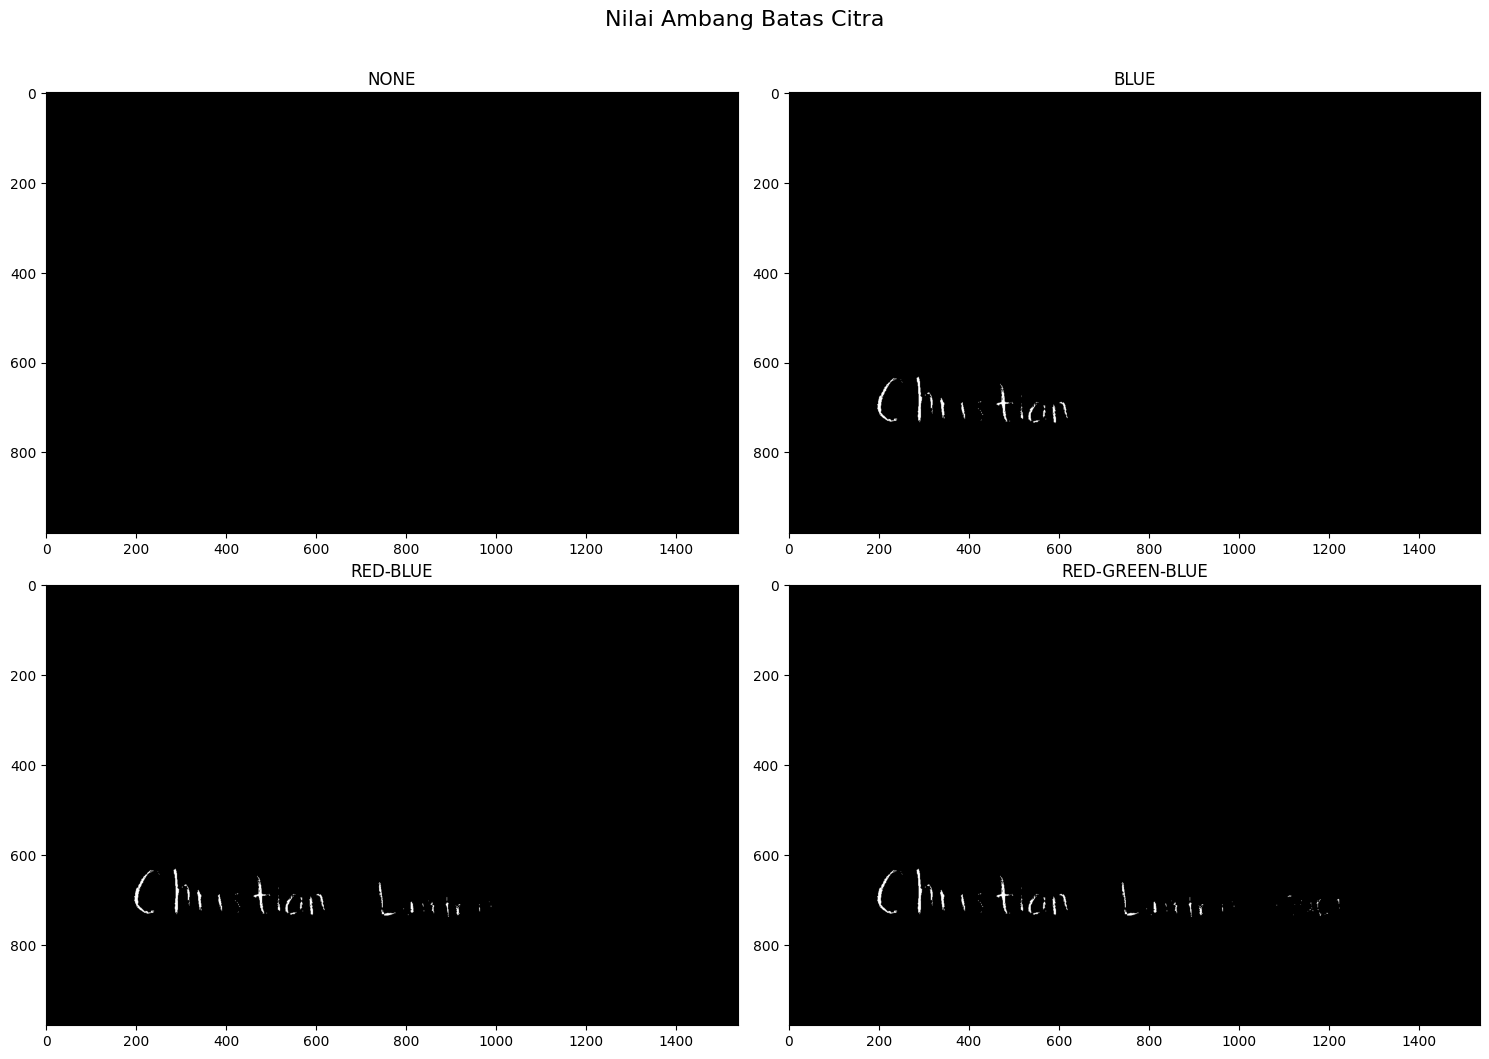

In [9]:
titles2 = ['NONE', 'BLUE', 'RED-BLUE', 'RED-GREEN-BLUE']
images2 = [none_img, only_blue, red_blue, red_green_blue]

plt.figure(figsize=(15, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images2[i], cmap='gray')
    plt.title(titles2[i])
    plt.axis('on')
plt.tight_layout(); plt.suptitle("Nilai Ambang Batas Citra", fontsize=16, y=1.05); plt.show()

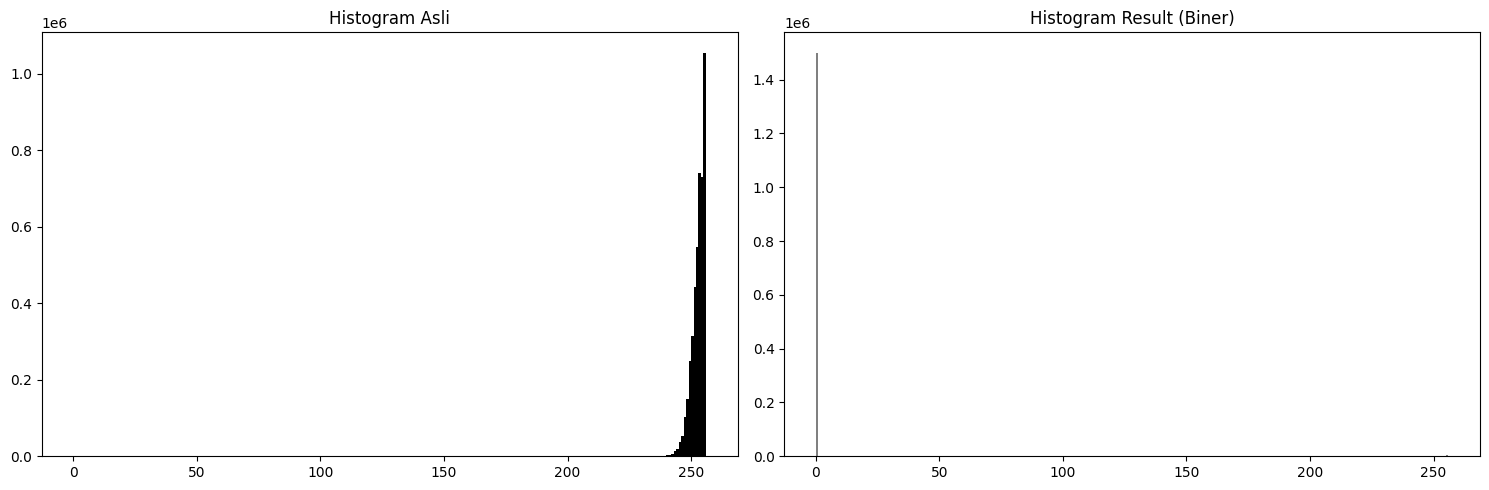

In [10]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1); plt.hist(img_rgb.ravel(), 256, range=[0, 256], color='black'); plt.title("Histogram Asli")
plt.subplot(1, 2, 2); plt.hist(red_green_blue.ravel(), 256, range=[0, 256], color='gray'); plt.title("Histogram Result (Biner)")
plt.tight_layout(); plt.show()